In [3]:
!pip install mne

In [13]:
import mne
raw = mne.io.read_raw_edf('/content/S003R08.edf', preload=True)



Extracting EDF parameters from /content/S003R08.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...


In [27]:
fs=raw.info['sfreq']
print(fs)
raw.annotations

160.0


<Annotations | 30 segments: T0 (15), T1 (7), T2 (8)>

In [28]:
channel_index=[];
for i,ch in enumerate(raw.ch_names):
  if ch =="C3.." or ch =="C4..":
    channel_index.append(i)
    print(ch)
channel_index

C3..
C4..


[8, 12]

In [35]:
events, event_id = mne.events_from_annotations(raw)
epochs=mne.Epochs(raw,events,event_id=event_id,tmin=0.0,tmax=4.0,baseline=None,preload=True);

Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 30 events and 641 original time points ...
0 bad epochs dropped


In [46]:
epochs_t1=epochs['T1']
epochs_t2=epochs['T2']
print(epochs_t1.get_data().shape)

(7, 64, 641)



Channel: C3..
Band                    T1 Left        T2 Right    Diff (T1-T2)
------------------------------------------------------------
Mu (8-12Hz)          2.5866e-11      2.2966e-11      2.8995e-12
Beta (12-30Hz)       6.8529e-12      7.3759e-12     -5.2293e-13
Mu      T1=2.59e-11    T2=2.30e-11
Beta    T1=6.85e-12  T2=7.38e-12
Avg     T1=1.64e-11   T2=1.52e-11
Diff (T1-T2) = 1.19e-12


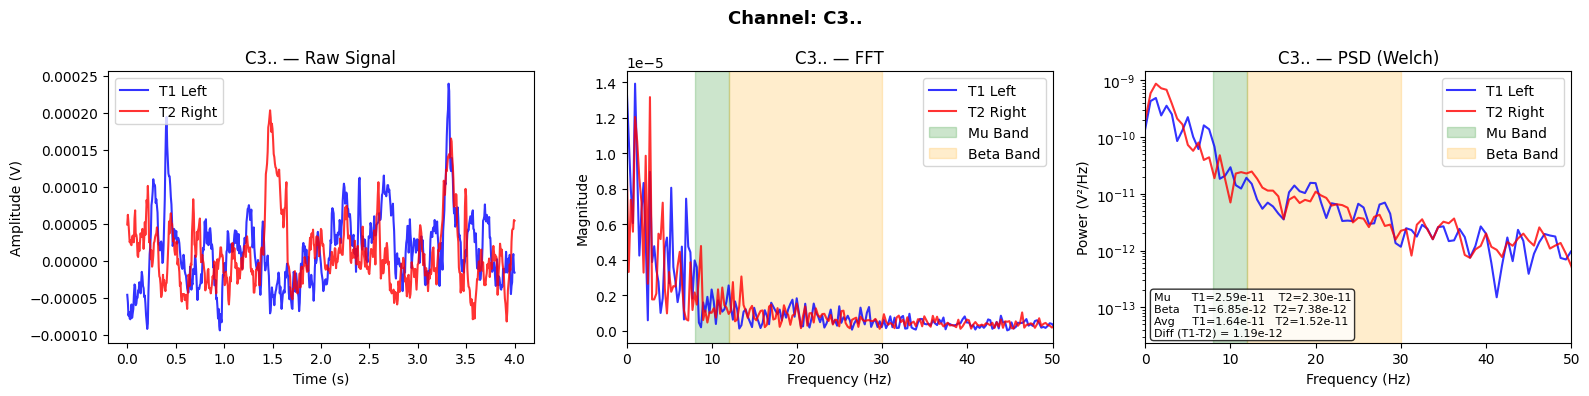


Channel: C4..
Band                    T1 Left        T2 Right    Diff (T1-T2)
------------------------------------------------------------
Mu (8-12Hz)          2.0456e-11      2.2216e-11     -1.7607e-12
Beta (12-30Hz)       6.8359e-12      8.2519e-12     -1.4160e-12
Mu      T1=2.05e-11    T2=2.22e-11
Beta    T1=6.84e-12  T2=8.25e-12
Avg     T1=1.36e-11   T2=1.52e-11
Diff (T1-T2) = -1.59e-12


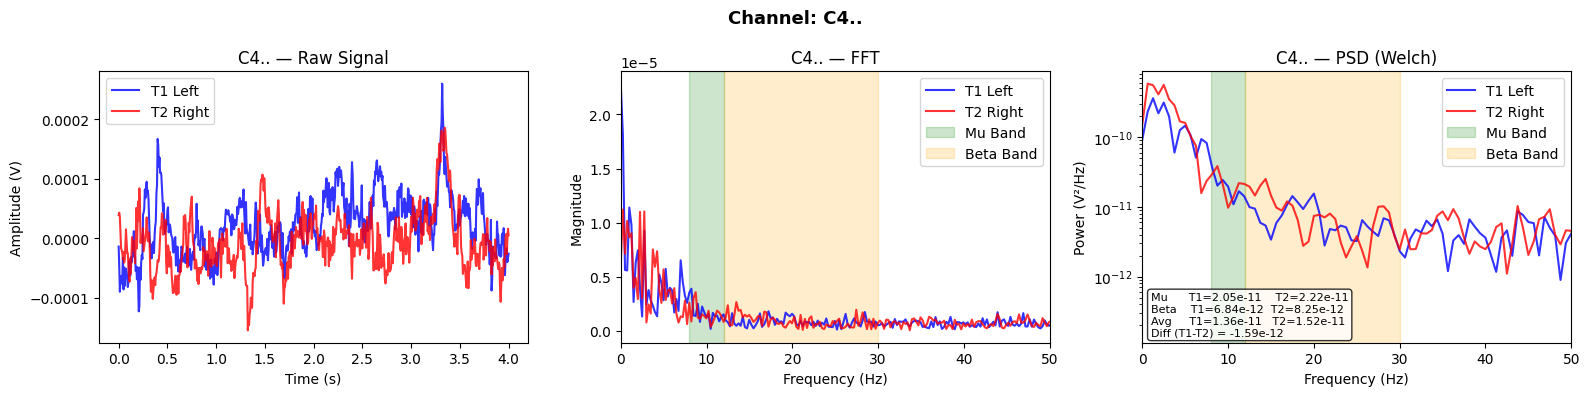

In [69]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.signal import welch

fs   = 160
time = np.linspace(0, 4, 641)

for i in range(len(channel_index)):
    t1_sig = epochs_t1.get_data()[0, channel_index[i], :]
    t2_sig = epochs_t2.get_data()[0, channel_index[i], :]

    # ─────────────────────────────────────
    # FFT
    # ─────────────────────────────────────
    N         = len(t1_sig)
    freqs_fft = np.fft.rfftfreq(N, d=1/fs)

    fft_t1 = np.abs(np.fft.rfft(t1_sig)) / N
    fft_t2 = np.abs(np.fft.rfft(t2_sig)) / N

    # ─────────────────────────────────────
    # PSD (Welch Method)
    # ─────────────────────────────────────
    freqs_psd, psd_t1 = welch(t1_sig, fs=fs, nperseg=256)
    freqs_psd, psd_t2 = welch(t2_sig, fs=fs, nperseg=256)

    # ─────────────────────────────────────
    # Plot
    # ─────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    ch_name = epochs.ch_names[channel_index[i]]

    # Raw Signal
    axes[0].plot(time, t1_sig, label='T1 Left',  color='blue', alpha=0.8)
    axes[0].plot(time, t2_sig, label='T2 Right', color='red',  alpha=0.8)
    axes[0].set_title(f'{ch_name} — Raw Signal')
    axes[0].set_xlabel('Time (s)')
    axes[0].set_ylabel('Amplitude (V)')
    axes[0].legend()

    # FFT
    axes[1].plot(freqs_fft, fft_t1, label='T1 Left',  color='blue', alpha=0.8)
    axes[1].plot(freqs_fft, fft_t2, label='T2 Right', color='red',  alpha=0.8)
    axes[1].set_title(f'{ch_name} — FFT')
    axes[1].set_xlabel('Frequency (Hz)')
    axes[1].set_ylabel('Magnitude')
    axes[1].set_xlim(0, 50)   # focus on 0-50 Hz
    axes[1].axvspan(8, 12, color='green', alpha=0.2, label='Mu Band')
    axes[1].axvspan(12, 30, color='orange', alpha=0.2, label='Beta Band')
    axes[1].legend()

    # PSD
    axes[2].semilogy(freqs_psd, psd_t1, label='T1 Left',  color='blue', alpha=0.8)
    axes[2].semilogy(freqs_psd, psd_t2, label='T2 Right', color='red',  alpha=0.8)
    axes[2].set_title(f'{ch_name} — PSD (Welch)')
    axes[2].set_xlabel('Frequency (Hz)')
    axes[2].set_ylabel('Power (V²/Hz)')
    axes[2].set_xlim(0, 50)
    axes[2].axvspan(8, 12, color='green', alpha=0.2, label='Mu Band')
    axes[2].axvspan(12, 30, color='orange', alpha=0.2, label='Beta Band')
    axes[2].legend()

    plt.suptitle(f'Channel: {ch_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    # ─────────────────────────────────────
    # Average Band Power
    # ─────────────────────────────────────
    def band_power(psd, freqs, low, high):
        idx = np.where((freqs >= low) & (freqs <= high))[0]
        return np.mean(psd[idx])

    t1_mu   = band_power(psd_t1, freqs_psd, 8,  12)
    t2_mu   = band_power(psd_t2, freqs_psd, 8,  12)
    t1_beta = band_power(psd_t1, freqs_psd, 12, 30)
    t2_beta = band_power(psd_t2, freqs_psd, 12, 30)

    # Print
    print(f"\nChannel: {ch_name}")
    print(f"{'Band':<15} {'T1 Left':>15} {'T2 Right':>15} {'Diff (T1-T2)':>15}")
    print("-" * 60)
    print(f"{'Mu (8-12Hz)':<15} {t1_mu:>15.4e} {t2_mu:>15.4e} {t1_mu - t2_mu:>15.4e}")
    print(f"{'Beta (12-30Hz)':<15} {t1_beta:>15.4e} {t2_beta:>15.4e} {t1_beta - t2_beta:>15.4e}")

    # Add text box on PSD plot
    avg_t1 = np.mean([t1_mu, t1_beta])
    avg_t2 = np.mean([t2_mu, t2_beta])
    diff   = avg_t1 - avg_t2

    textstr = (
        f"Mu      T1={t1_mu:.2e}    T2={t2_mu:.2e}\n"
        f"Beta    T1={t1_beta:.2e}  T2={t2_beta:.2e}\n"
        f"Avg     T1={avg_t1:.2e}   T2={avg_t2:.2e}\n"
        f"Diff (T1-T2) = {diff:.2e}"
    )

    print(textstr)
    axes[2].text(0.02, 0.02, textstr,
                 transform=axes[2].transAxes,
                 fontsize=8,
                 verticalalignment='bottom',
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.suptitle(f'Channel: {ch_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
    plt.show()

In [71]:
from scipy.signal import welch
import numpy as np

fs = 160

def band_power(signal, fs, low, high):
    freqs, psd = welch(signal, fs=fs, nperseg=256)
    idx = np.where((freqs >= low) & (freqs <= high))[0]
    return np.mean(psd[idx])

# ─────────────────────────────────────
# Feature Extraction
# ─────────────────────────────────────
X = []
y = []

# T1 → Class 0 (Left Hand)
t1_data = epochs_t1.get_data()
for trial in range(t1_data.shape[0]):
    c3_sig = t1_data[trial, channel_index[0], :]
    c4_sig = t1_data[trial, channel_index[1], :]

    c3_mu   = band_power(c3_sig, fs, 8,  12)
    c3_beta = band_power(c3_sig, fs, 12, 30)
    c4_mu   = band_power(c4_sig, fs, 8,  12)
    c4_beta = band_power(c4_sig, fs, 12, 30)

    X.append([c3_mu, c3_beta, c4_mu, c4_beta])
    y.append(0)   # Class 0 = Left Hand

# T2 → Class 1 (Right Hand)
t2_data = epochs_t2.get_data()
for trial in range(t2_data.shape[0]):
    c3_sig = t2_data[trial, channel_index[0], :]
    c4_sig = t2_data[trial, channel_index[1], :]

    c3_mu   = band_power(c3_sig, fs, 8,  12)
    c3_beta = band_power(c3_sig, fs, 12, 30)
    c4_mu   = band_power(c4_sig, fs, 8,  12)
    c4_beta = band_power(c4_sig, fs, 12, 30)

    X.append([c3_mu, c3_beta, c4_mu, c4_beta])
    y.append(1)   # Class 1 = Right Hand

X = np.array(X)
y = np.array(y)

# ─────────────────────────────────────
# Print Feature Table
# ─────────────────────────────────────
print("=" * 75)
print(f"{'Trial':<8} {'Class':<12} {'C3 Mu':>12} {'C3 Beta':>12} {'C4 Mu':>12} {'C4 Beta':>12}")
print("=" * 75)

for i in range(len(X)):
    label = "0 (Left)" if y[i] == 0 else "1 (Right)"
    print(f"{i+1:<8} {label:<12} {X[i,0]:>12.4e} {X[i,1]:>12.4e} {X[i,2]:>12.4e} {X[i,3]:>12.4e}")

print("=" * 75)
print(f"\nTotal Samples : {len(X)}")
print(f"Class 0 (Left)  : {np.sum(y==0)} trials")
print(f"Class 1 (Right) : {np.sum(y==1)} trials")
print(f"Feature Shape   : {X.shape}")   # → (15, 4)

Trial    Class               C3 Mu      C3 Beta        C4 Mu      C4 Beta
1        0 (Left)       2.5866e-11   6.8529e-12   2.0456e-11   6.8359e-12
2        0 (Left)       2.6132e-11   7.8546e-12   2.2059e-11   9.4349e-12
3        0 (Left)       3.8462e-11   7.7614e-12   4.1783e-11   8.4974e-12
4        0 (Left)       4.5792e-11   1.0648e-11   6.8197e-11   9.0128e-12
5        0 (Left)       2.2626e-11   7.3399e-12   1.9867e-11   7.4870e-12
6        0 (Left)       2.8425e-11   8.4831e-12   2.7005e-11   1.0914e-11
7        0 (Left)       2.4369e-11   8.1130e-12   2.7445e-11   7.5645e-12
8        1 (Right)      2.2966e-11   7.3759e-12   2.2216e-11   8.2519e-12
9        1 (Right)      3.5222e-11   8.7811e-12   2.8724e-11   7.7194e-12
10       1 (Right)      3.7594e-11   7.1552e-12   2.1715e-11   7.3261e-12
11       1 (Right)      2.3327e-11   6.0186e-12   2.5520e-11   7.3481e-12
12       1 (Right)      5.1080e-11   7.1894e-12   4.0225e-11   1.1427e-11
13       1 (Right)      5.1095e-11   7

     LDA — Leave One Out CV
  Each Fold : [0. 1. 0. 1. 1. 1. 1. 0. 0. 1. 0. 1. 1. 1. 1.]
  ───────────────────────────────────
  Accuracy  : 66.67%
  Std Dev   : 47.14%
  Correct   : 10/15

  Classification Report
              precision    recall  f1-score   support

   Left Hand       0.62      0.71      0.67         7
  Right Hand       0.71      0.62      0.67         8

    accuracy                           0.67        15
   macro avg       0.67      0.67      0.67        15
weighted avg       0.67      0.67      0.67        15



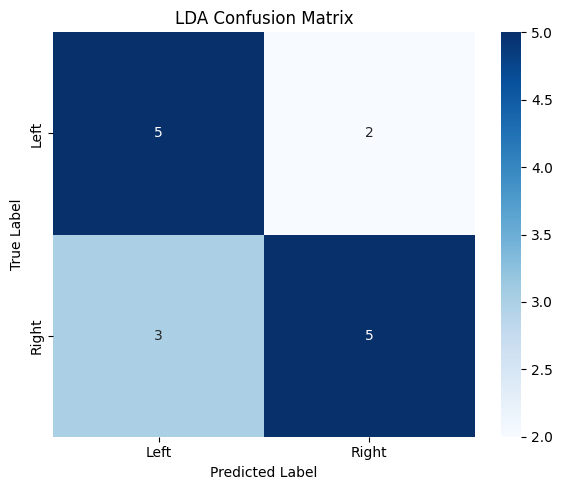

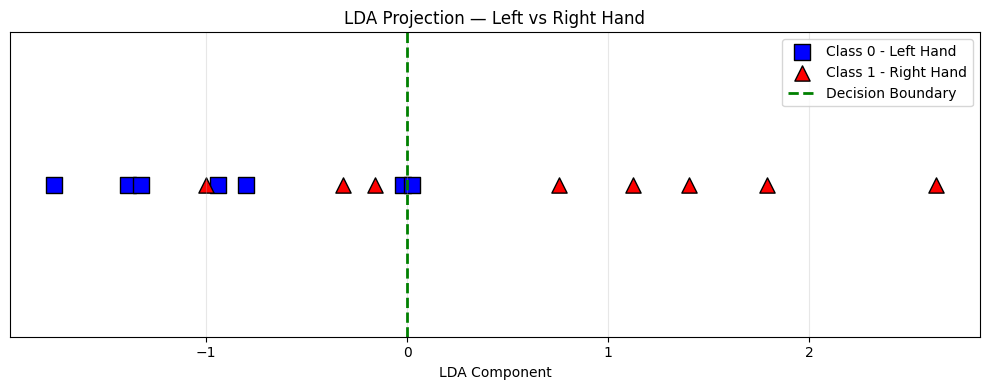

In [74]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# ─────────────────────────────────────
# Scale Features
# ─────────────────────────────────────
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ─────────────────────────────────────
# LDA with Leave One Out CV
# (best for small datasets like yours)
# ─────────────────────────────────────
lda    = LinearDiscriminantAnalysis()
loo    = LeaveOneOut()
scores = cross_val_score(lda, X_scaled, y, cv=loo, scoring='accuracy')

print("=" * 40)
print("     LDA — Leave One Out CV")
print("=" * 40)
print(f"  Each Fold : {scores}")
print(f"  {'─'*35}")
print(f"  Accuracy  : {scores.mean()*100:.2f}%")
print(f"  Std Dev   : {scores.std()*100:.2f}%")
print(f"  Correct   : {int(scores.sum())}/{len(scores)}")

# ─────────────────────────────────────
# Fit on Full Data for Confusion Matrix
# ─────────────────────────────────────
lda.fit(X_scaled, y)
y_pred = lda.predict(X_scaled)

print("\n" + "=" * 40)
print("  Classification Report")
print("=" * 40)
print(classification_report(y, y_pred, target_names=['Left Hand', 'Right Hand']))

# ─────────────────────────────────────
# Confusion Matrix
# ─────────────────────────────────────
cm = confusion_matrix(y, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Left', 'Right'],
            yticklabels=['Left', 'Right'])
plt.title('LDA Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# ─────────────────────────────────────
# Plot LDA Decision Boundary
# ─────────────────────────────────────
# Transform to 1D LDA space
X_lda = lda.transform(X_scaled)

plt.figure(figsize=(10, 4))
plt.scatter(X_lda[y==0], np.zeros(np.sum(y==0)),
            marker='s', color='blue', s=120,
            label='Class 0 - Left Hand', edgecolors='black')
plt.scatter(X_lda[y==1], np.zeros(np.sum(y==1)),
            marker='^', color='red', s=120,
            label='Class 1 - Right Hand', edgecolors='black')
plt.axvline(x=0, color='green', linestyle='--', linewidth=2, label='Decision Boundary')
plt.title('LDA Projection — Left vs Right Hand')
plt.xlabel('LDA Component')
plt.yticks([])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [78]:
test_samples = np.array([
    # C3_mu,    C3_beta,   C4_mu,     C4_beta
    [2.5e-11,  6.8e-12,   2.0e-11,   6.5e-12],   # Sample 1
    [2.2e-11,  7.3e-12,   2.3e-11,   8.1e-12],   # Sample 2
    [2.8e-11,  6.5e-12,   1.9e-11,   6.2e-12],   # Sample 3
    [2.1e-11,  7.5e-12,   2.4e-11,   8.5e-12],   # Sample 4
    [2.6e-11,  6.9e-12,   2.1e-11,   6.8e-12],   # Sample 5
])
test_scaled = scaler.transform(test_samples)
predictions  = lda.predict(test_scaled)
probabilities = lda.predict_proba(test_scaled)
predictions

array([1, 0, 1, 0, 1])